# Sequence design: one Monte Carlo design run in Z(H)–Z(P) space

This notebook demonstrates the same Monte Carlo sequence-design logic used in the production code in `SequenceDesign/ZHP_N70_S20_parallel`.

It shows **one** optimization run toward a single target point in the `Z(H)`–`Z(P)` plane. In production, the same optimization is run from **8 independent initial sequences**, and the **best-scoring** result is retained.

Throughout this notebook:

- `"1"` = sticker
- `"0"` = spacer

Internally, the production optimizer uses `"S"` and `"X"`. The notebook converts between these two representations only at the interface to the design code.

In [1]:
from pathlib import Path
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- locate repo root robustly ---
cwd = Path.cwd().resolve()

if cwd.name == "notebooks":
    ROOT = cwd.parent
elif (cwd / "SequenceDesign").exists():
    ROOT = cwd
else:
    ROOT = cwd
    while ROOT != ROOT.parent and not (ROOT / "SequenceDesign").exists():
        ROOT = ROOT.parent

SEQDESIGN_DIR = ROOT / "SequenceDesign" / "ZHP_N70_S20_parallel"

if not SEQDESIGN_DIR.exists():
    raise FileNotFoundError(
        "Could not find SequenceDesign/ZHP_N70_S20_parallel. "
        "Run this notebook from the StickerPatterning repo."
    )

if str(SEQDESIGN_DIR) not in sys.path:
    sys.path.insert(0, str(SEQDESIGN_DIR))

print("Repository root:", ROOT)
print("Sequence design directory:", SEQDESIGN_DIR)

H_LOOKUP = SEQDESIGN_DIR / "H_Z_lookup_100k.pkl"
P_LOOKUP = SEQDESIGN_DIR / "P_Z_lookup_100k.pkl"

Repository root: /Users/davidkanovich/GitHub/StickerPatterning
Sequence design directory: /Users/davidkanovich/GitHub/StickerPatterning/SequenceDesign/ZHP_N70_S20_parallel


## Files used in this notebook

This notebook uses the same code path as the production design workflow:

- `seq_hp_opt.py` for the production single-target optimizer wrapper
- `SeqGen_Feasibility_space.py` for the `SeqDesign` Monte Carlo annealing logic
- `PatternMetric.py` for raw `H` and `P`
- `NormMetric.py` for `Z(H)` and `Z(P)`

In [2]:
import PatternMetric
import NormMetric
import seq_hp_opt
from SeqGen_Feasibility_space import SeqDesign

print("PatternMetric:", Path(PatternMetric.__file__).resolve())
print("NormMetric:   ", Path(NormMetric.__file__).resolve())
print("seq_hp_opt:   ", Path(seq_hp_opt.__file__).resolve())

PatternMetric: /Users/davidkanovich/GitHub/StickerPatterning/SequenceDesign/ZHP_N70_S20_parallel/PatternMetric.py
NormMetric:    /Users/davidkanovich/GitHub/StickerPatterning/SequenceDesign/ZHP_N70_S20_parallel/NormMetric.py
seq_hp_opt:    /Users/davidkanovich/GitHub/StickerPatterning/SequenceDesign/ZHP_N70_S20_parallel/seq_hp_opt.py


## Helpers

The production optimizer uses `'S'` as the sticker character and `'X'` as the spacer character. For notebook readability, we display sequences as binary strings and glyph strings.

The helper functions below only convert representations; they do **not** change the optimization logic.

In [3]:
def sx_to_binary(seq_sx: str) -> str:
    return "".join("1" if c == "S" else "0" for c in seq_sx)

def binary_to_sx(seq_binary: str) -> str:
    return "".join("S" if c == "1" else "X" for c in seq_binary)

def glyph(seq_binary: str) -> str:
    return "".join("●" if c == "1" else "·" for c in seq_binary)

def compute_metrics_from_binary(seq_binary: str):
    H_raw = PatternMetric.StickerPattern(seq_binary, "1").calc_H_ave()
    P_raw = PatternMetric.StickerPattern(seq_binary, "1").process_patch()

    print("Using H lookup:", H_LOOKUP)
    print("Using P lookup:", P_LOOKUP)

    Z_H = NormMetric.normalised_H(
        seq_binary,
        sticker="1",
        lookup_path=str(H_LOOKUP),
    )
    Z_P = NormMetric.normalised_P(
        seq_binary,
        sticker="1",
        lookup_path=str(P_LOOKUP),
    )

    return {
        "sequence": seq_binary,
        "L": len(seq_binary),
        "k": seq_binary.count("1"),
        "H_raw": float(H_raw),
        "P_raw": float(P_raw),
        "Z_H": float(Z_H),
        "Z_P": float(Z_P),
    }

## Choose one target

This notebook demonstrates one design run toward one target point in the `Z(H)`–`Z(P)` plane.

You can change these values later, but it is best to stay within the composition used by the production lookup tables.

In [20]:
L = 70
k = 20

target_ZH = 4
target_ZP = 7.5

base_seed = 7
n_epochs = 12
steps_per_epoch = 20000

print(f"L={L}, k={k}")
print(f"Target: Z(H)={target_ZH:.3f}, Z(P)={target_ZP:.3f}")
print(f"Seed={base_seed}, epochs={n_epochs}, steps/epoch={steps_per_epoch}")

L=70, k=20
Target: Z(H)=4.000, Z(P)=7.500
Seed=7, epochs=12, steps/epoch=20000


## Define the objective

The production design code minimizes squared error in Z-space:

The production design code minimizes squared error in Z-space:

$$
E = \frac{1}{2}\left(Z(P) - Z(P)_{\mathrm{target}}\right)^2
  + \frac{1}{2}\left(Z(H) - Z(H)_{\mathrm{target}}\right)^2
$$

This is the same objective used by `SeqDesign.energy(...)` in `SeqGen_Feasibility_space.py`.

In [21]:
# Reproducible initialization, matching the production code style
random.seed(base_seed)
np.random.seed(base_seed)

sd = SeqDesign(k, L, target_ZH, target_ZP, sticker_char="S")

initial_binary = "".join("1" if x == "S" else "0" for x in sd._init_sequence())
initial_metrics = compute_metrics_from_binary(initial_binary)

pd.DataFrame([initial_metrics])

Using H lookup: /Users/davidkanovich/GitHub/StickerPatterning/SequenceDesign/ZHP_N70_S20_parallel/H_Z_lookup_100k.pkl
Using P lookup: /Users/davidkanovich/GitHub/StickerPatterning/SequenceDesign/ZHP_N70_S20_parallel/P_Z_lookup_100k.pkl


,sequence,L,k,H_raw,P_raw,Z_H,Z_P
0,0010100000010001001000000000001001100000000001...,70,20,0.86228,0.368421,-0.605648,0.933775


In [22]:
print("Initial binary sequence:")
print(initial_binary)
print()
print("Initial visual pattern:")
print(glyph(initial_binary))

Initial binary sequence:
0010100000010001001000000000001001100000000001100000110011100100111010

Initial visual pattern:
··●·●······●···●··●···········●··●●··········●●·····●●··●●●··●··●●●·●·


## Run one optimization trajectory

The code below uses the same annealed swap logic implemented by `SeqDesign.generate_seq(...)`:

- initialize one random sequence with fixed `L` and `k`
- propose swaps between sticker and spacer positions
- accept or reject moves using the annealing rule
- keep track of the best sequence found so far

This notebook runs **one** optimization only. In production, the workflow runs **8 independent restarts** and keeps the best result.

In [23]:
import os

print("Old cwd:", Path.cwd())
os.chdir(SEQDESIGN_DIR)
print("New cwd:", Path.cwd())

# Reset seeds so the full run is reproducible
random.seed(base_seed)
np.random.seed(base_seed)

best_seq_sx, epoch_steps, cost_curve = sd.generate_seq(
    nStep=n_epochs,
    steps=steps_per_epoch,
    log_epochs=True,
    log_steps=False,
)

best_seq_binary = sx_to_binary(best_seq_sx)
final_metrics = compute_metrics_from_binary(best_seq_binary)

trajectory_df = pd.DataFrame({
    "step": epoch_steps,
    "cost": cost_curve,
})

trajectory_df

Old cwd: /Users/davidkanovich/GitHub/StickerPatterning/SequenceDesign/ZHP_N70_S20_parallel
New cwd: /Users/davidkanovich/GitHub/StickerPatterning/SequenceDesign/ZHP_N70_S20_parallel
[1/12] epochs complete | best_cost=16.9018 | epoch_cost=16.9018 | elapsed=4.1s
[2/12] epochs complete | best_cost=16.8987 | epoch_cost=16.8987 | elapsed=7.8s
[3/12] epochs complete | best_cost=16.8987 | epoch_cost=16.8987 | elapsed=11.6s
[4/12] epochs complete | best_cost=16.8987 | epoch_cost=16.8987 | elapsed=15.5s
[5/12] epochs complete | best_cost=16.8987 | epoch_cost=16.8987 | elapsed=19.2s
[6/12] epochs complete | best_cost=16.8987 | epoch_cost=16.8987 | elapsed=22.9s
[7/12] epochs complete | best_cost=16.8987 | epoch_cost=16.8987 | elapsed=26.7s
[8/12] epochs complete | best_cost=16.8987 | epoch_cost=16.8987 | elapsed=30.4s
[9/12] epochs complete | best_cost=16.8847 | epoch_cost=16.8847 | elapsed=34.9s
[10/12] epochs complete | best_cost=16.8847 | epoch_cost=16.8847 | elapsed=38.7s
[11/12] epochs comp

,step,cost
0,20000,16.901839
1,40000,16.898722
2,60000,16.898722
3,80000,16.898722
4,100000,16.898722
5,120000,16.898722
6,140000,16.898722
7,160000,16.898722
8,180000,16.884705
9,200000,16.884705


In [24]:
pd.DataFrame([
    {
        "state": "initial",
        **initial_metrics,
        "cost": 0.5 * (initial_metrics["Z_P"] - target_ZP)**2 + 0.5 * (initial_metrics["Z_H"] - target_ZH)**2,
    },
    {
        "state": "final",
        **final_metrics,
        "cost": 0.5 * (final_metrics["Z_P"] - target_ZP)**2 + 0.5 * (final_metrics["Z_H"] - target_ZH)**2,
    },
])

,state,sequence,L,k,H_raw,P_raw,Z_H,Z_P,cost
0,initial,0010100000010001001000000000001001100000000001...,70,20,0.862280,0.368421,-0.605648,0.933775,32.163648
1,final,0110000110000011000000110000001100000110000110...,70,20,0.898441,0.526316,0.714315,2.706913,16.884705


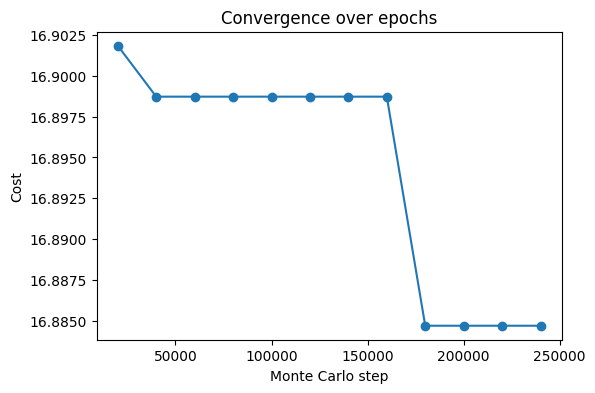

In [25]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(trajectory_df["step"], trajectory_df["cost"], marker="o")
ax.set_xlabel("Monte Carlo step")
ax.set_ylabel("Cost")
ax.set_title("Convergence over epochs")
plt.show()

## Closing note

This notebook demonstrates the same Monte Carlo design logic used by the production scripts, but in a compact single-target, single-run format.

`sequence_analysis.ipynb` explains how the raw and normalized patterning metrics are computed. The full scripts should be used for large-scale target scans or production sequence design runs.